In [9]:
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

# Initialization

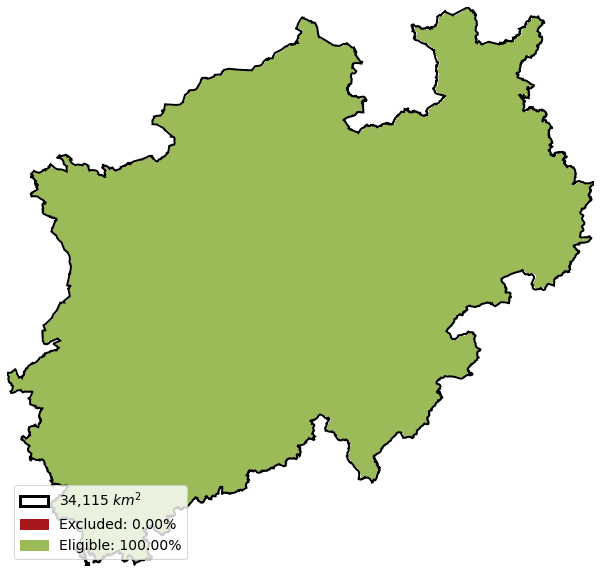

In [7]:
# CREATING AN EXLCUSION CALCULATOR OBJECT - where clause
ec = gl.ExclusionCalculator(region=r"C:\Users\s.ryberg\FZJ\data\regions\gadm\gadm36_1.shp", where="HASC_1='DE.NW'")
ec.draw()

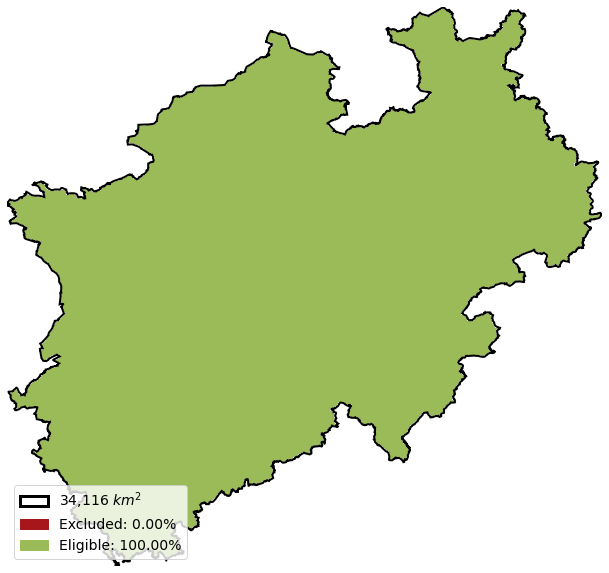

In [8]:
# CREATING AN EXLCUSION CALCULATOR OBJECT - with srs and pixelRes
ec = gl.ExclusionCalculator(region=r"C:\Users\s.ryberg\FZJ\data\regions\gadm\gadm36_1.shp", where="HASC_1='DE.NW'", srs="LAEA", pixelRes=50)
ec.draw()

In [14]:
ec.region.mask.shape
print( type(ec.region) )
print( type(ec.region.extent) )

<class 'geokit.core.regionmask.RegionMask'>
<class 'geokit.core.extent.Extent'>


In [15]:
ec.region.extent

xMin: 433250.000000
xMax: 689850.000000
yMin: 3988250.000000
yMax: 4229300.000000
srs: PROJCS["unnamed",GEOGCS["GRS 1980(IUGG, 1980)",DATUM["unknown",SPHEROID["GRS80",6378137,298.257222101],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",13.83715248235352],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1]]

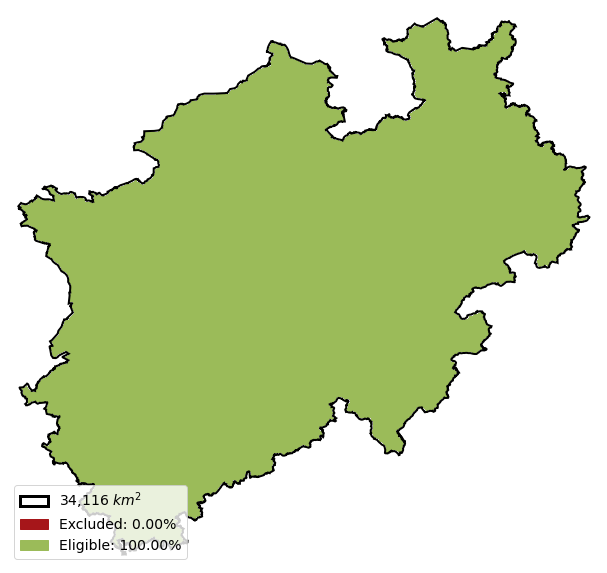

In [16]:
ec = gl.ExclusionCalculator(
    region=r"C:\Users\s.ryberg\FZJ\data\regions\gadm\gadm36_1.shp", 
    where="HASC_1='DE.NW'", 
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000)
ec.draw()

In [17]:
ec.region.mask.shape

(5021, 5332)

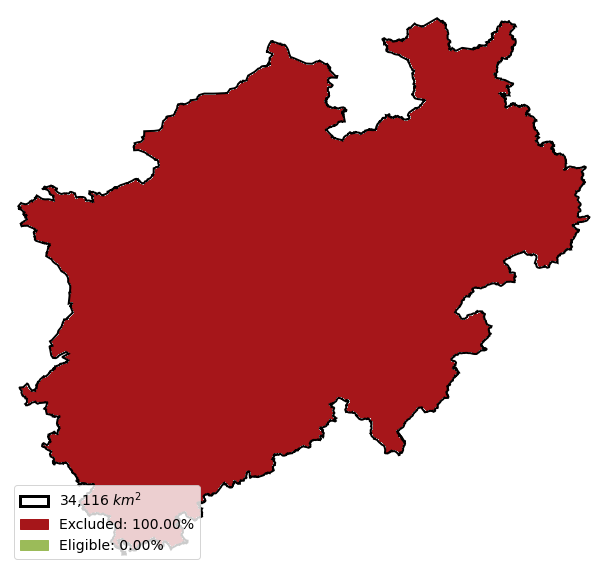

In [18]:
# CREATING AN EXLCUSION CALCULATOR OBJECT - with initialValue
ec = gl.ExclusionCalculator(
    region=r"C:\Users\s.ryberg\FZJ\data\regions\gadm\gadm36_1.shp", 
    where="HASC_1='DE.NW'", 
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000,
    initialValue=False)
ec.draw()

# Exclude Raster

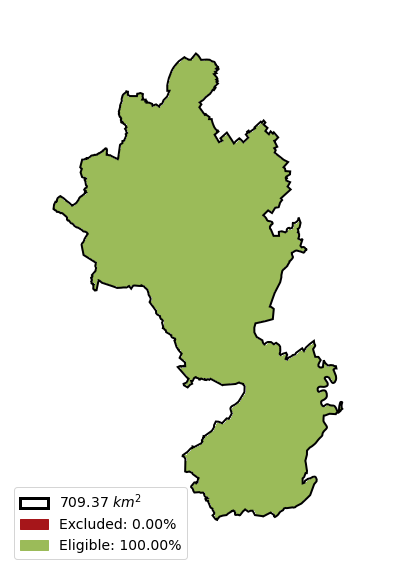

In [2]:
def make_new_ec(**kwargs):
    
    ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        **kwargs)
    return ec
ec = make_new_ec()
ec.draw()

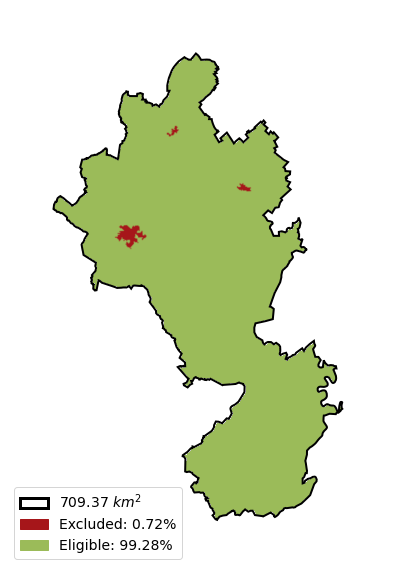

In [3]:
# Exclude Raster - Simple CLC with specific value
clc_path = r"C:\Users\s.ryberg\FZJ\data\geography\land_cover\clc_2018\u2018_clc2018_v2020_20u1_raster100m\u2018_clc2018_v2020_20u1_raster100m\DATA\U2018_CLC2018_V2020_20u1.tif"
ec.excludeRasterType(source=clc_path, value=1)

ec.draw()

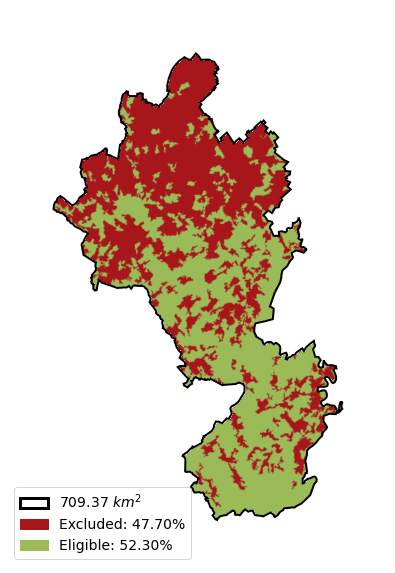

In [26]:
# Exclude Raster - Simple CLC with a range of values

# Simple way
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value=(1,2))

# More complex way
# 1-2 -> settlement areas
# 12 -> industrial areas
# 21-23 -> forests
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]")

ec.draw()

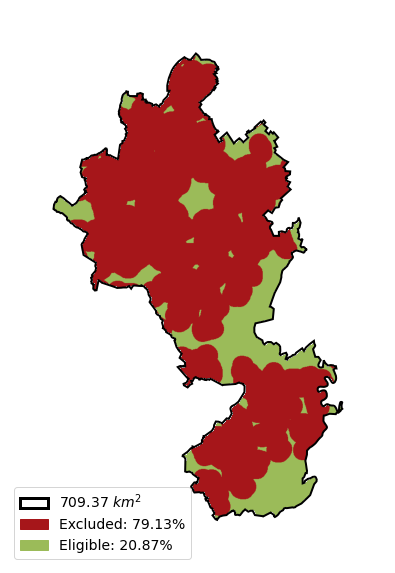

In [28]:

# Exclude Raster - with Buffer

ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value=(1,2))

ec.draw()

100.0
100.0
20.873729951471194


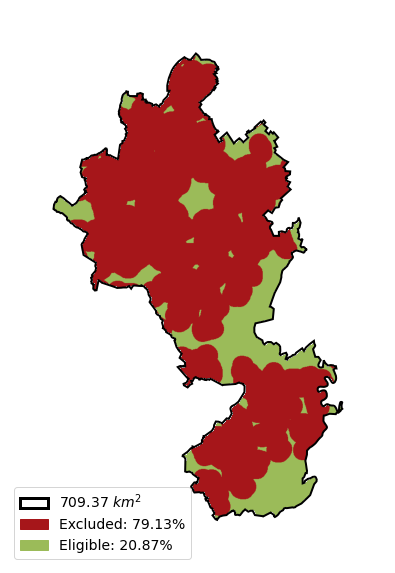

In [32]:

# Exclude Raster - mode Include
# GOTCHYA!! Ordering matters a lot!!!!

ec = make_new_ec()
print(ec.percentAvailable)

ec.excludeRasterType(source=clc_path, value=(1,2), buffer=1000)
print(ec.percentAvailable)

ec.excludeRasterType(source=clc_path, value=11, mode="include")
print(ec.percentAvailable)

ec.draw()

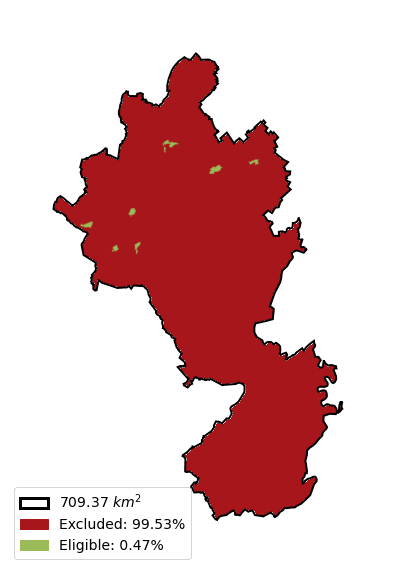

In [34]:

# Exclude Raster - mode Include version 2

ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=False)

ec.excludeRasterType(source=clc_path, value=11, mode="include")

ec.draw()

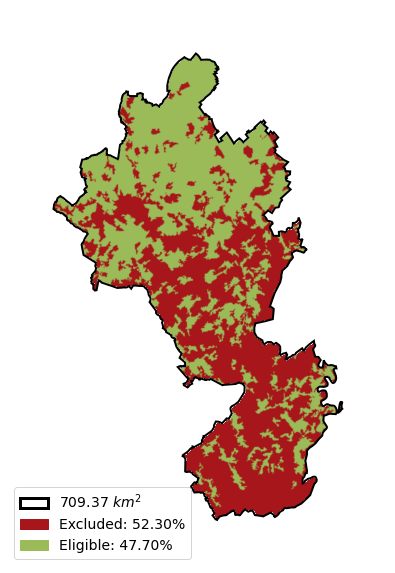

In [38]:

# Exclude Raster - mode Invert
# More complex way
# 1-2 -> settlement areas
# 12 -> industrial areas
# 21-23 -> forests
ec = make_new_ec()
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]", invert=True)

ec.draw()

In [ ]:

# Exclude Raster - resolutionDiv

In [ ]:

# Exclude Raster - prewarp

In [ ]:

# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

In [42]:
# Exclude Raster - DEM Mosaic
ec = make_new_ec()
dem_raster = ec.region.extent.rasterMosaic(r"C:\Users\s.ryberg\FZJ\data\geography\DEM\SRTM\*.hgt")

<class 'osgeo.gdal.Dataset'>


C:\Users\s.ryberg\AppData\Local\Continuum\anaconda3\envs\glaes\lib\site-packages\geokit\core\raster.py:1559: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(h, cax=cbax, **tmp)


AxHands(ax=<matplotlib.axes._axes.Axes object at 0x000002208BF0BC40>, handles=<matplotlib.image.AxesImage object at 0x000002208CD47670>, cbar=<matplotlib.colorbar.Colorbar object at 0x000002208CD479A0>)

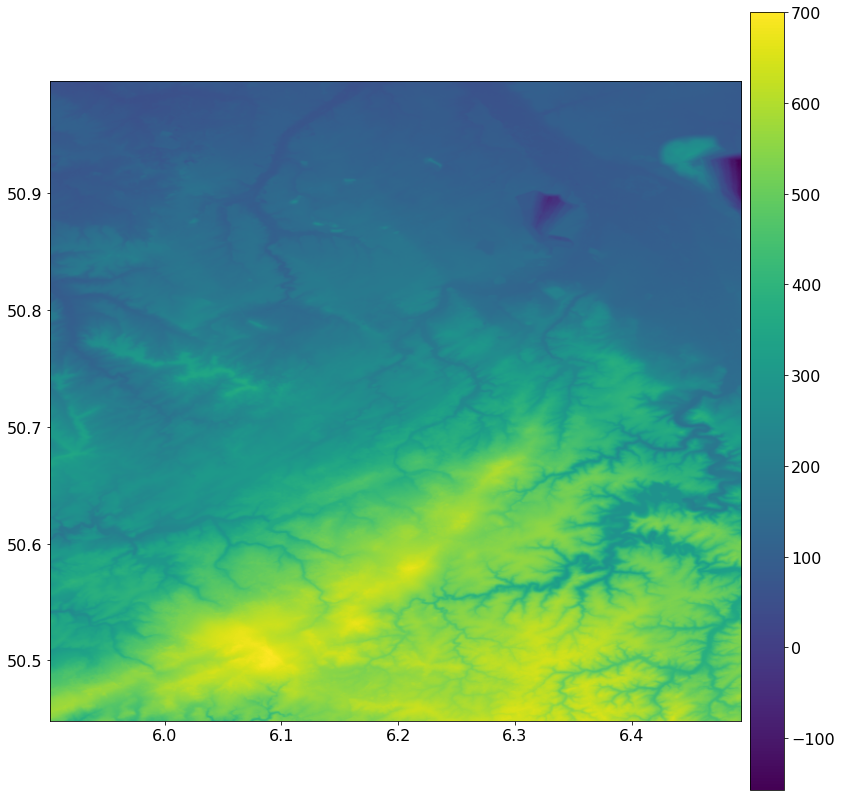

In [44]:
print(type(dem_raster))
gk.drawRaster(dem_raster)

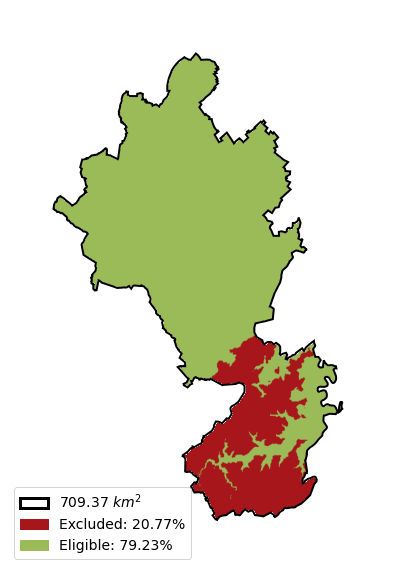

In [47]:
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

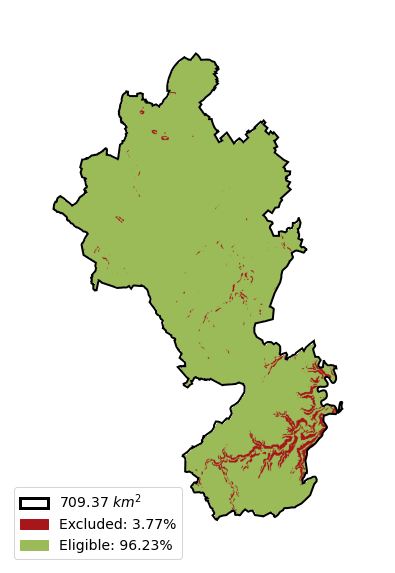

In [56]:
# Exclude Raster - DEM Gradient Mosaic
dem_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM"),
    processor=lambda x: np.degrees(np.arctan(x))
)



ec = make_new_ec()
ec.excludeRasterType(dem_gradiate_raster, value=(15, None), resampleAlg="mode")

ec.draw()

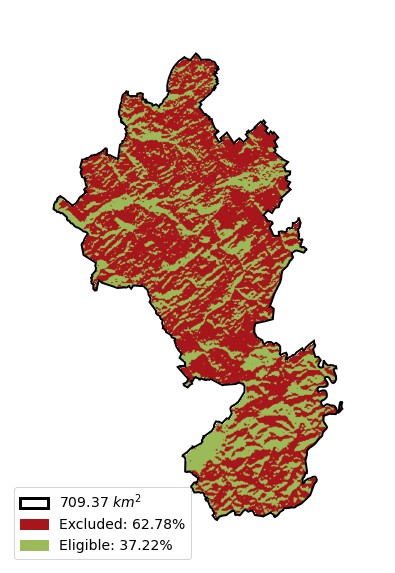

In [57]:
# Exclude Raster - DEM Gradient Mosaic - North-South
dem_ns_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)


ec = make_new_ec()
ec.excludeRasterType(dem_ns_gradiate_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# Exclude Vector

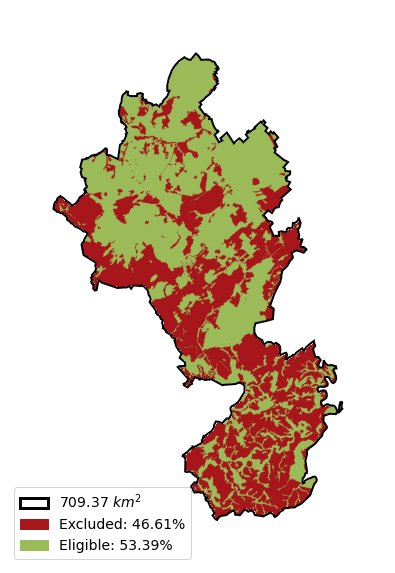

In [4]:
# Exclude Vector - Simple source w/ where clause

ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\protected_areas\protected_planet\WDPA_Jul2020-shapefile2\WDPA_Jul2020-shapefile-polygons.shp",
    where="IUCN_CAT='V'",
)

ec.draw()

In [5]:
!mkdir intermediate_files

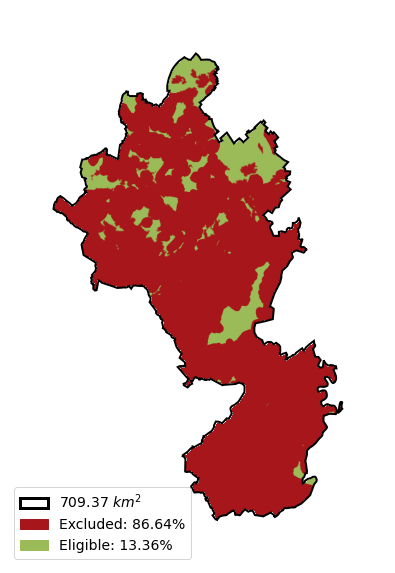

In [12]:
# Exclude Vector - Simple source w/ where clause and intermediate

ec = make_new_ec()

ec.excludeRasterType(clc_path, value=(1,2))

ec.excludeVectorType(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\protected_areas\protected_planet\WDPA_Jul2020-shapefile2\WDPA_Jul2020-shapefile-polygons.shp",
    where="IUCN_CAT='V'",
    buffer=400,
    intermediate="./intermediate_files/wdpa_V.tif"
)

ec.draw()

C:\Users\s.ryberg\AppData\Local\Continuum\anaconda3\envs\glaes\lib\site-packages\geokit\core\raster.py:1559: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(h, cax=cbax, **tmp)


AxHands(ax=<matplotlib.axes._axes.Axes object at 0x0000018B883528E0>, handles=<matplotlib.image.AxesImage object at 0x0000018B88239EE0>, cbar=<matplotlib.colorbar.Colorbar object at 0x0000018B8826E370>)

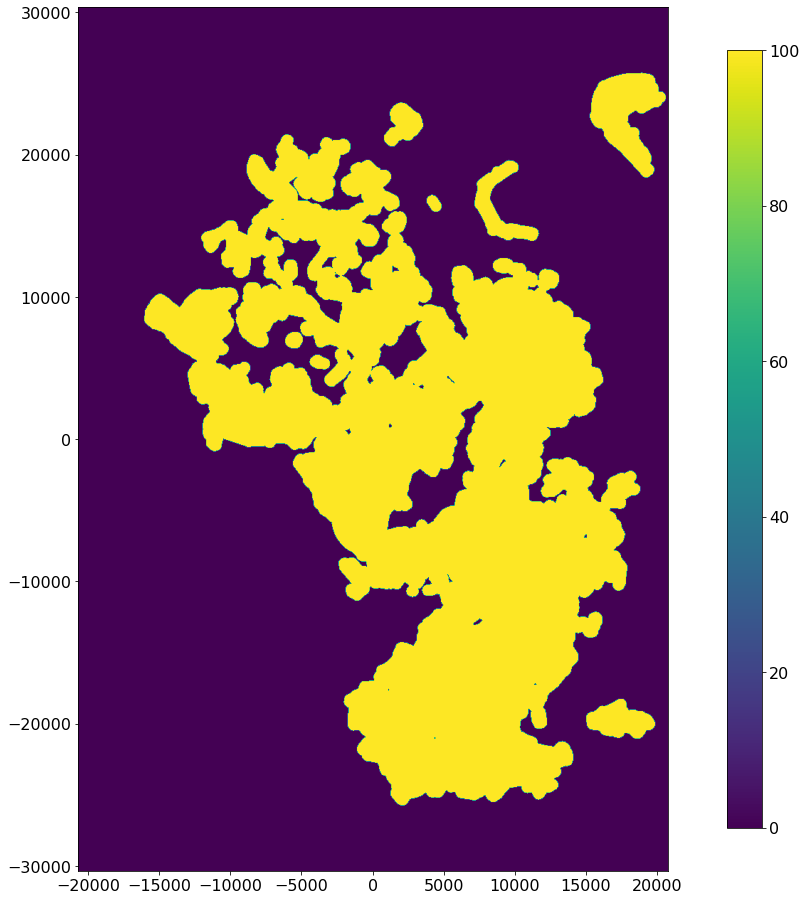

In [13]:
gk.drawRaster("./intermediate_files/wdpa_V.tif")

In [ ]:

# Exclude Vector - Simple source w/ where clause & buffer

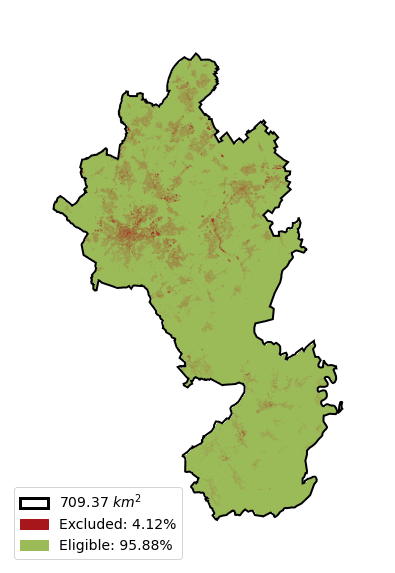

In [21]:
# Exclude Vector - resolutionDiv

ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_buildings_a_free_1.shp",
    resolutionDiv=8,
    forceMaskShape=True
)

ec.draw()

In [22]:
ec.save("test_resolution_div_8.tif")

'test_resolution_div_8.tif'

# Save results

In [25]:
ec.save?

Signature: ec.save(output, threshold=None, **kwargs)
Docstring:
Save the current availability matrix to a raster file

Output will be a byte-valued raster with the following convention:
    0     -> unavailable
    1..99 -> Semi-available
    100   -> fully eligibile
    255   -> "no data" (out of region)

Parameters:
-----------
output : str
    The path of the output raster file
    * Must end in ".tif"

threshold : float; optional
    The acceptable threshold indicating an available pixel
    * Use this to process the availability matrix before saving it (will
      save a little bit of space)

kwargs:
    * All keyword arguments are passed on to a call to
      geokit.RegionMask.createRaster
    * Most notably:
        - 'dtype' is used to define the data type of the resulting raster
        - 'overwrite' is used to force overwrite an existing file
File:      c:\users\s.ryberg\fzj\workdir\2034_glaes_workshop\glaes\glaes\core\exclusioncalculator.py
Type:      method


In [28]:
ec.save("exclusion_result.tif", threshold=90)

'exclusion_result.tif'

# Prior Datasets

In [33]:
from glaes import Priors
Priors.loadDirectory(r"C:\Users\s.ryberg\FZJ\data\geography\glaes_priors")

In [3]:
# After moving files into the glaes/data/priors directory...
# from glaes import Priors

import glaes as gl
import geokit as gk
import numpy as np

In [ ]:
# What are the prior datasets

In [ ]:
# How to install Priors

In [10]:
# How to access priors
roads_prior = gl.Priors['roads_main_proximity']

In [6]:
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

C:\Users\s.ryberg\AppData\Local\Continuum\anaconda3\envs\glaes\lib\site-packages\geokit\core\raster.py:1559: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(h, cax=cbax, **tmp)


AxHands(ax=<matplotlib.axes._axes.Axes object at 0x000002611DD9DC10>, handles=<matplotlib.image.AxesImage object at 0x000002611FC74430>, cbar=<matplotlib.colorbar.Colorbar object at 0x000002611FC8E370>)

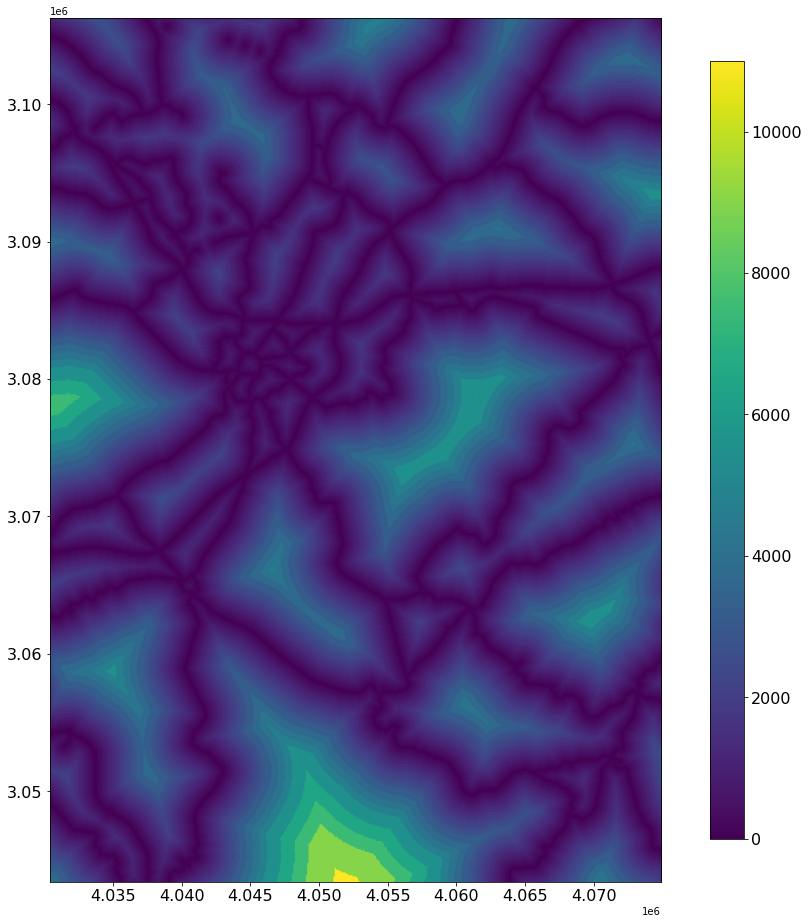

In [12]:
gk.drawRaster(roads_prior.generateRaster(ec.region.extent))

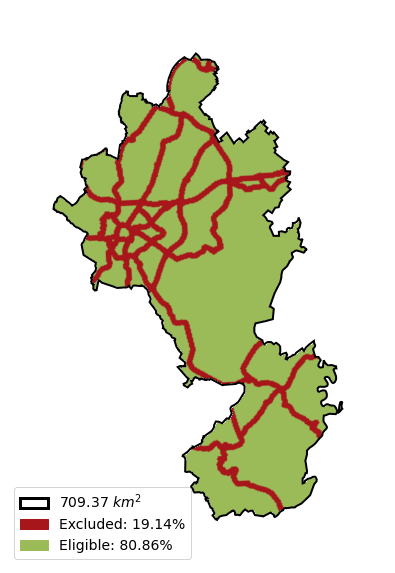

In [14]:
# How to use priors
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

ec.("roads_main_proximity", value=(0,300))

ec.draw()

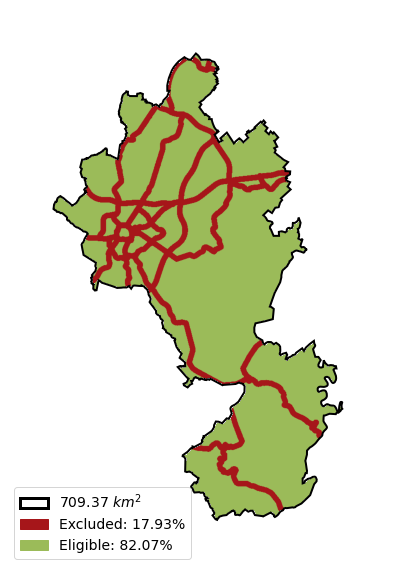

In [19]:
# Showcase of how the prior dataset is faster!
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

ec.excludeVectorType(r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp", 
                     where="fclass='primary' OR fclass='motorway' OR fclass='trunk'",
                     buffer=300)

ec.draw()

In [20]:
gl.Priors.listKeys

access_distance
agriculture_arable_proximity
agriculture_heterogeneous_proximity
agriculture_pasture_proximity
agriculture_permanent_crop_proximity
agriculture_proximity
airfield_proximity
airport_proximity
camping_proximity
connection_distance
dni_threshold
elevation_threshold
ghi_threshold
industrial_proximity
lake_proximity
leisure_proximity
mining_proximity
ocean_proximity
power_line_proximity
protected_biosphere_proximity
protected_bird_proximity
protected_habitat_proximity
protected_landscape_proximity
protected_natural_monument_proximity
protected_park_proximity
protected_reserve_proximity
protected_wilderness_proximity
railway_proximity
river_proximity
roads_main_proximity
roads_proximity
roads_secondary_proximity
sand_proximity
settlement_proximity
settlement_urban_proximity
slope_north_facing_threshold
slope_threshold
touristic_proximity
waterbody_proximity
wetland_proximity
windspeed_100m_threshold
windspeed_50m_threshold
woodland_coniferous_proximity
woodland_deciduous_prox

In [27]:
# How to produce a prior dataset
# !mkdir prior_temp
indications = []
for buffer_value in [0,50,100,250,500,1000,2000,5000]:
    print(buffer_value)
    indications.append( 
        ec.region.indicateValues(
            source=clc_path,
            value=(1,2),
            buffer=buffer_value
        )
    )


0
50
100
250
500
1000
2000
5000


In [31]:
prior_data = np.full_like(ec.region.mask, 5001, dtype=np.uint16, )
for ind_mat, buffer_distance in zip( indications[::-1], [0,50,100,250,500,1000,2000,5000][::-1]):
    prior_data[ ind_mat>0.5 ] = buffer_distance

In [33]:
ec.region.createRaster( output="prior_example.tif", data=prior_data )

'prior_example.tif'

# Exclude Set

In [4]:
# Exclude Set
import pandas as pd
exclusion_set = pd.read_csv(gl._test_data_['sample_exclusion_set.csv'])
exclusion_set.loc[2,'value'] = "fclass='motorway' OR fclass='primary' OR fclass='trunk'"

exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,fclass='motorway' OR fclass='primary' OR fclas...,200.0


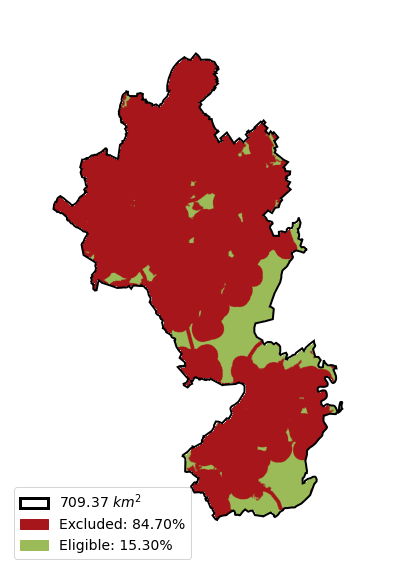

In [5]:
ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        initialValue=True)

## Apply exclusions from the given set
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=clc_path,
    osm_roads=r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp",
)

## Draw result
ec.draw()

# Smopy

In [46]:
import matplotlib.pyplot as plt

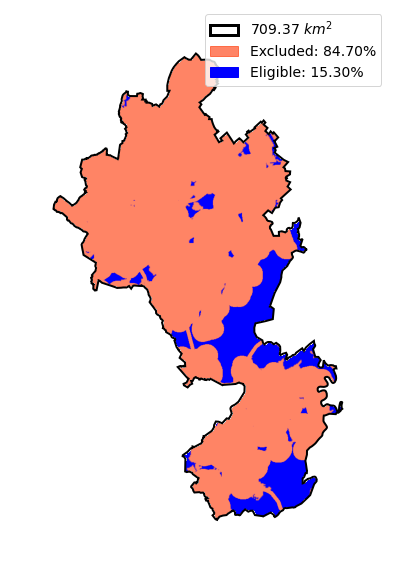

In [55]:
ec.draw(
    goodColor="blue",
    excludedColor=(1.0, 0.2, 0.0, 0.6),
    legendargs={'loc': 'upper right'},)

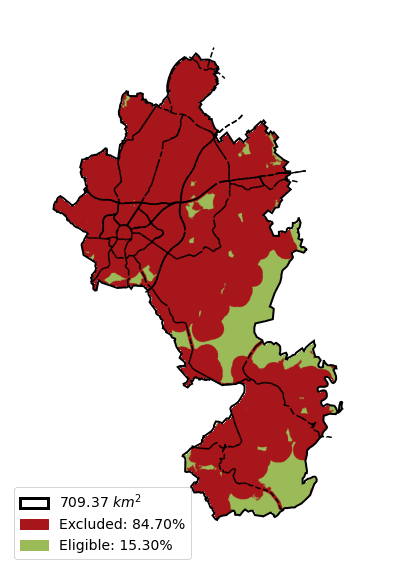

In [60]:
ax = ec.draw()

roads = gk.vector.extractFeatures(r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_roads_free_1.shp", 
                                  where="fclass='motorway' OR fclass='primary' OR fclass='trunk'",
                                  geom=ec.region.geometry)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)

plt.show()

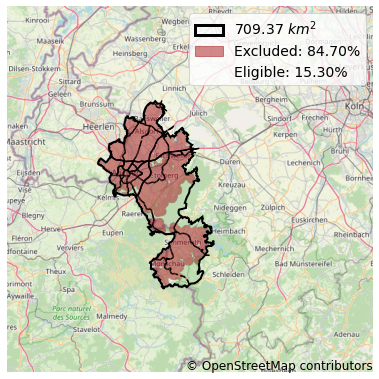

In [74]:
# Draw with Smopy
## Importance of attribution statement!!

ax = ec.drawWithSmopyBasemap(
    zoom=9,
    legendargs={'loc': 'upper right'},)


gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=gk.srs.EPSG3857)

plt.show()

In [72]:
ec.drawWithSmopyBasemap?

Signature:
ec.drawWithSmopyBasemap(
    zoom=4,
    excludedColor=(0.6509803921568628, 0.08627450980392157, 0.10196078431372549, 0.5019607843137255),
    ax=None,
    figsize=None,
    smopy_kwargs={'attribution': '© OpenStreetMap contributors', 'attribution_size': 12},
    **kwargs,
)
Docstring:
This wrapper around the original ExclusionCalculator.draw function adds a basemap bethind the drawn eligibility map

NOTE:
* The basemap is drawn using the Smopy python package. See here: https://github.com/rossant/smopy
* Be careful to adhere to the usage guidelines of the chosen tile source
    - By default, this source is OSM. See here: https://wiki.openstreetmap.org/wiki/Tile_servers

!IMPORTANT! If you will publish any images drawn with this method, it's likely that the tile source
will require an attribution to be written on the image. For example, if using OSM tile (the default),
you have to write "© OpenStreetMap contributors" clearly on the map. But this is different for each
tile sou

# Placements

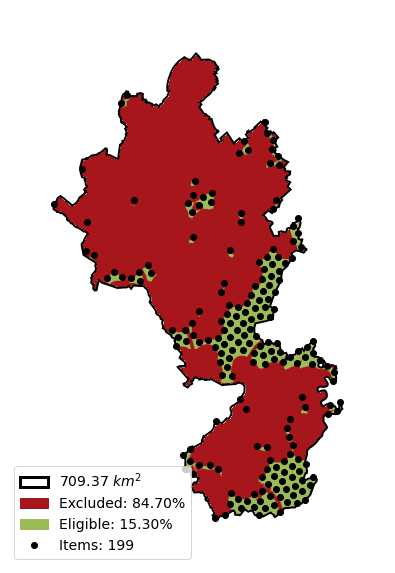

In [79]:
# Placement algorithm - simple separation distance
points = ec.distributeItems( 1000, outputSRS=gk.srs.EPSG4326 )

ec.draw()

In [83]:
ec.itemCoords[:5]

array([[ 6.08760705, 50.90962575],
       [ 6.07838603, 50.90152659],
       [ 6.30081551, 50.8831131 ],
       [ 6.30434424, 50.87277242],
       [ 6.31373924, 50.86602167]])

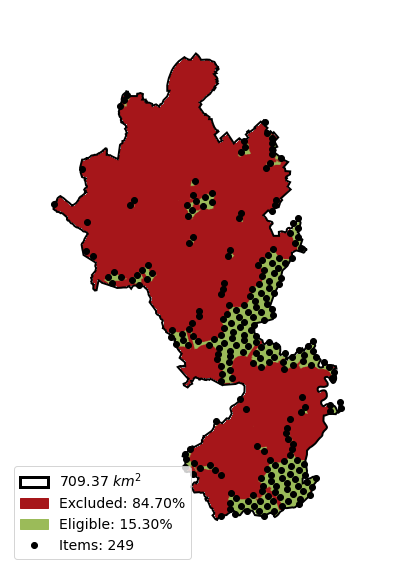

In [6]:
# Placement algorithm - directional separation distance
# East = 0
# North = 90
# West = 180
# South = 270

points = ec.distributeItems( (1400, 600), axialDirection=0, outputSRS=gk.srs.EPSG4326 )

ec.draw()

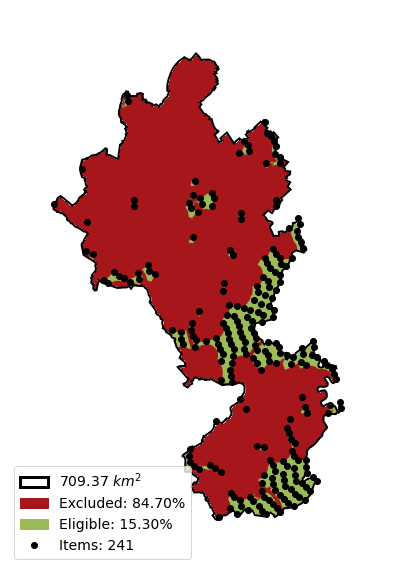

In [11]:
# Placement algorithm - directional separation distance from a raster file
# East = 0
# North = 90
# West = 180
# South = 270

points = ec.distributeItems( 
    (1400, 600), 
    axialDirection="C:/Users/s.ryberg/FZJ/repos/res/reskit/weather/Era5Source/data/ERA5_wind_direction_100m_mean.tiff", 
    outputSRS=gk.srs.EPSG4326 )

ec.draw()

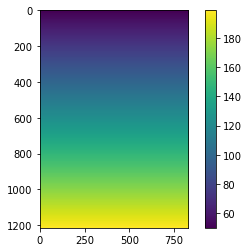

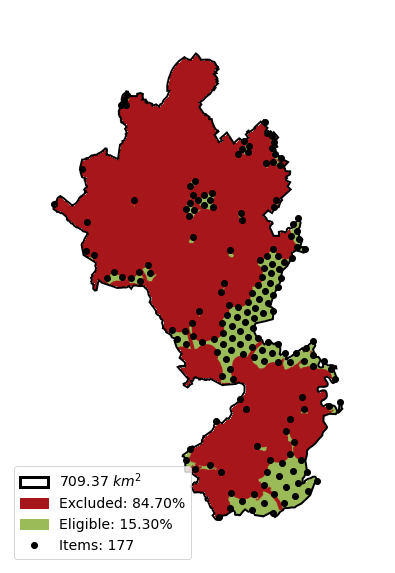

In [17]:
# Placement algorithm - variable separation distance
mat = np.zeros_like(ec.region.mask, dtype=np.uint8)
for i in range(mat.shape[0]):
    mat[i,:] = (200-50)*i/(mat.shape[0]) + 50

h = plt.imshow(mat)
plt.colorbar(h)
plt.show()

rotor_diam_raster = ec.region.createRaster(output="rotor_diameter.tif", data=mat)

points = ec.distributeItems( 
    separation=8.0,
    sepScaling=rotor_diam_raster)

ec.draw()

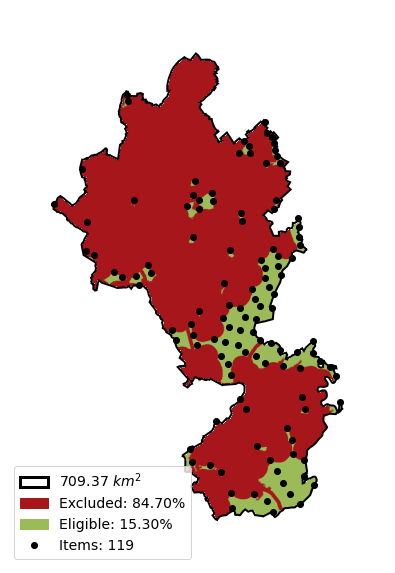

In [20]:
points = ec.distributeItems( 
    separation=(15.0,8.0),
    sepScaling=rotor_diam_raster,
    axialDirection="C:/Users/s.ryberg/FZJ/repos/res/reskit/weather/Era5Source/data/ERA5_wind_direction_100m_mean.tiff", 
    outputSRS=gk.srs.EPSG4326 )

ec.draw()

In [1]:
# Placement algorithm - getting areas
ec.save("placement_exclusion_result.tif")

points = ec.distributeItems( separation=1000, asArea=False, output="placment_points.shp")

areas = ec.distributeItems( separation=1000, asArea=True, output="placment_areas.shp")

ec.draw()

NameError: name 'ec' is not defined

In [52]:
# extracting info for placements 
points = gk.LocationSet(ec.itemCoords, srs=ec.srs)

mean_wind_speeds = gk.raster.interpolateValues(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\global_wind_atlas\gwa3_250_wind-speed_100m.NRW.tif",
    points=points)


dist_from_settlement = gk.raster.interpolateValues(
    source=gl.Priors.settlement_proximity.generateRaster(ec.region.extent),
    points=points)

In [48]:
df = pd.DataFrame()
df['geom'] = gk.LocationSet(ec.itemCoords, srs=ec.srs).asGeom()
df['windspeed'] = mean_wind_speeds
df['settledist'] = dist_from_settlement

gk.vector.createVector(df, output="placement_points_with_data.shp")

'placement_points_with_data.shp'

In [49]:
df

,geom,windspeed,settledist
0,POINT (6.08760705339576 50.9096257544788 0),7.391802,1050.0
1,POINT (6.07838602738474 50.9015265947583 0),6.976899,1250.0
2,POINT (6.30081550772289 50.8831130974103 0),7.321034,1050.0
3,POINT (6.30434424452087 50.8727724170833 0),7.424338,1350.0
4,POINT (6.31373924191766 50.866021674016 0),7.055402,1450.0
...,...,...,...
194,POINT (6.30104393494824 50.5055588713916 0),7.601233,3250.0
195,POINT (6.32376566345361 50.5023899917281 0),7.673443,4750.0
196,POINT (6.29045936075381 50.4992750769464 0),7.523646,3250.0
197,POINT (6.23936737194443 50.4993047457608 0),7.862500,1050.0


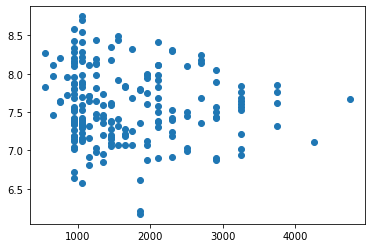

In [46]:
# plot settlement distance vs wind speed
plt.scatter(df['settledist'],df['windspeed'])
plt.show()

In [135]:
areas = ec.distributeItems( separation=1000, asArea=True)
areas

[<osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FABD50> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139F981E0> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9CEA0> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FAB150> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAA1B70> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAA2300> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x0000026139FAB030> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9EC90> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AA9EF90> >,
 <osgeo.ogr.Geometry; proxy of <Swig Object of type 'OGRGeometryShadow *' at 0x000002613AAB9300> >,
